In [6]:
# Cell: Evaluation + Mismatch Analysis
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

Now let us do the basic metrics + confusion matrix

Classification Report (ratings vs VADER):

              precision    recall  f1-score   support

    Negative      0.836     0.589     0.691      3177
     Neutral      0.052     0.192     0.081       402
    Positive      0.865     0.845     0.855      6807

    accuracy                          0.742     10386
   macro avg      0.584     0.542     0.542     10386
weighted avg      0.824     0.742     0.775     10386



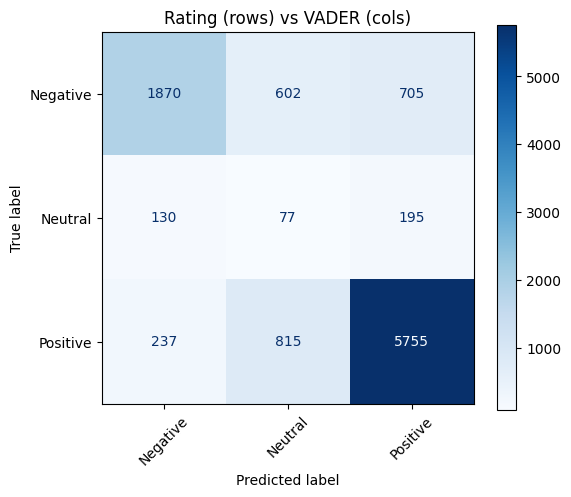

In [7]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_true = df['rating_sentiment']
y_pred = df['vader_sentiment']

print("Classification Report (ratings vs VADER):\n")
print(classification_report(y_true, y_pred, digits=3))

labels = ['Negative','Neutral','Positive']
cm = confusion_matrix(y_true, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(6,5))
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
plt.title("Rating (rows) vs VADER (cols)")
plt.show()


In [8]:
# Reload dataset
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

df = pd.read_csv("../data/clean/all_apps_clean.csv")
analyzer = SentimentIntensityAnalyzer()

# VADER scoring function
def get_vader_score(text):
    if pd.isna(text):
        return 0.0
    return analyzer.polarity_scores(str(text))['compound']

df['vader_compound'] = df['review_clean'].apply(get_vader_score)

# Map to labels (same thresholds we used)
def get_vader_label(compound):
    if compound >= 0.05:
        return 'Positive'
    elif compound <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

def get_rating_label(rating):
    if rating >= 4:
        return 'Positive'
    elif rating <= 2:
        return 'Negative'
    else:
        return 'Neutral'

df['vader_sentiment'] = df['vader_compound'].apply(get_vader_label)
df['rating_sentiment'] = df['rating'].apply(get_rating_label)

print("Loaded df with shape:", df.shape)
print("Sample:")
display(df[['app_name','rating','review_clean','vader_compound','vader_sentiment']].head())


Loaded df with shape: (10386, 19)
Sample:


,app_name,rating,review_clean,vader_compound,vader_sentiment
0,Cash App,1,keeps popping up as spam just horrible setup i...,-0.8020,Negative
1,Cash App,1,horrible app one day its totally working fine ...,-0.8106,Negative
2,Cash App,5,this ap has served me so well,0.4101,Positive
3,Cash App,5,the future of money good job babe you are asto...,0.6908,Positive
4,Cash App,5,my whole life depends on this appdoes wire tra...,0.2302,Positive
